Will be using the network in EI_STDP.ipynb where STDP is implemented on the synapses to the inhibitory neuron.
This seems to help the network find a steady state.

Here, we will explicitly compare the autaptic and non-autaptic networks in achieving synchrony.

In [1]:
''' import aqua '''
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA
from aqua.utils import * 
from aqua.plotting_functions import *

'''general imports''' 
import numpy as np
import pandas as pd
from brian2 import *
import matplotlib.pyplot as plt
import seaborn as sns
import pyspike as spk
from scipy.signal import convolve, windows
from scipy.stats import wasserstein_distance

from FT_metrics import *

WARNING    /home/liam/anaconda3/envs/aqua/lib/python3.14/site-packages/pyspike/__init__.py:40: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
 [py.warnings]


In [2]:
I_neuron = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0.2, 'f': 0., 'tau': 0.}

# strong autaptic neuron on RS resonator...
E1_neuron = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 5, 'c': -50, 'd': 100, 'e': 0.2, 'f': 250., 'tau': 0.}     # instantaneous autapse bc all synapses are instant.

E1_neuron_naut = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 5, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}     # instantaneous autapse bc all synapses are instant.

# non-autaptic neuron - RS resonator
E2_neuron = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

def visualise_connectivity(S):
    Ns = len(S.source)
    Nt = len(S.target)
    figure(figsize=(10, 4))
    subplot(121)
    plot(zeros(Ns), arange(Ns), 'ok', ms=10)
    plot(ones(Nt), arange(Nt), 'ok', ms=10)
    for i, j in zip(S.i, S.j):
        plot([0, 1], [i, j], '-k')
    xticks([0, 1], ['Source', 'Target'])
    ylabel('Neuron index')
    xlim(-0.1, 1.1)
    ylim(-1, max(Ns, Nt))
    subplot(122)
    plot(S.i, S.j, 'ok')
    xlim(-1, Ns)
    ylim(-1, Nt)
    xlabel('Source neuron index')
    ylabel('Target neuron index')

In [3]:
### Store the simulation parameters below. 

# DRIVING CURRENTS
INPUT_E1 = 220
INPUT_E2 = 120

# SYNAPSE STRENGTH
E1_TO_I = 80   
I_TO_E2 = -80

#  INHIBITORY PARAMETERS
THRESHOLD_OFFSET = 0
W_MAX = 100

# simulation parameters
T = 5000 # ms
dt = 0.1
N_iter = int(T/dt)


- - threshold - -


100%|██████████| 59999/59999 [00:07<00:00, 7590.03it/s]


ALL FS!!!


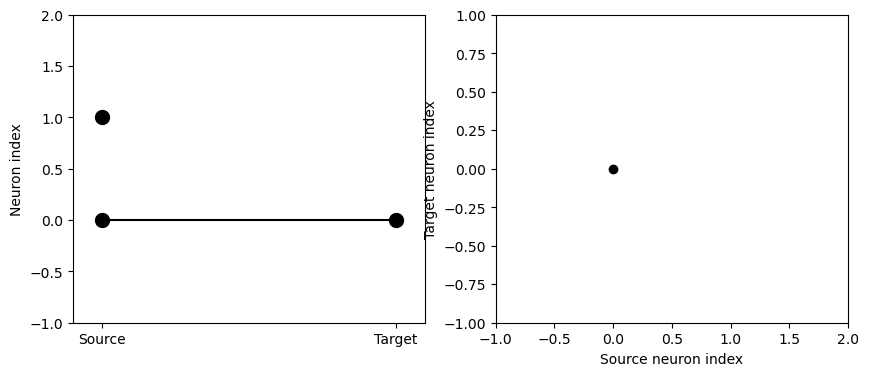

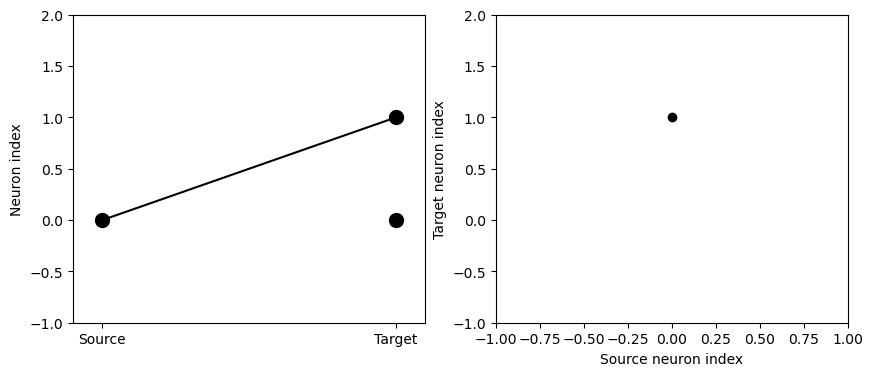

In [4]:
'''
- - - 3 neuron circuit with an autapse present - - - 
'''
start_scope()

# define the synapse at the population level, defined for excitatory and inhibitory populations
syn_eq = """
    dSyn_exc/dt = -(Syn_exc/t_exc)/ms : 1 
    t_exc : 1
    dSyn_inh/dt = -(Syn_inh/t_inh)/ms : 1 
    t_inh : 1
    g_total = Syn_exc + Syn_inh : 1 

"""

''' - - - define the excitatory population - - - '''
# neuron parameters
params_E = [E1_neuron, E2_neuron]      # 2 neurons

x_start = np.full(shape = (2, 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(2)

# create the batch
batch_E = batchAQUA(params_E)
batch_E.Initialise(x_start, t_start)

# create the input current - STEP CURRENT
I_h1 = INPUT_E1                          # driving current to autaptic neuron
I1 = I_h1 * np.ones(N_iter)         # stronger driving current to E1s
I_h2 = INPUT_E2                          # driving current to non-autaptic neuron
I2 = I_h2 * np.ones(N_iter)         # weaker current to E2

I_inj = np.array([I1, I2])
I_excTA = TimedArray(values = I_inj.T, dt = dt*ms, name = 'I_excTA')

# convert to brian2 with the standard autapse model
E, aut_E = batch_E.meetBrian(stimulus_name = I_excTA, synapse_eq = syn_eq)
E_uncoupled, aut_E_uncoupled = batch_E.meetBrian(stimulus_name = I_excTA, synapse_eq = syn_eq)
E_uncoupled.t_exc = 5
E_uncoupled.t_inh = 5

''' - - - define the inhibitory neuron - - - '''
param_I = [I_neuron]
x_start = np.array([[-60, 0, 0]])
t_start = np.array([0.])

# create batch 
batch_I = batchAQUA(param_I)
batch_I.Initialise(x_start, t_start)

# input current will be just subthreshold
threshold, _ = batch_I.get_threshold(idx = 0)
I_inh = np.array([(threshold - THRESHOLD_OFFSET)*np.ones(N_iter)])
I_inhTA = TimedArray(values = I_inh.T, dt = dt*ms, name = 'I_inhTA')

# create brian objects, no effective autapse here.
I, aut_I = batch_I.meetBrian(stimulus_name = I_inhTA, synapse_eq = syn_eq)


''' - - - create the synapses - - - '''
# create the synapses between E1 and E2...
# I_syn represents the synapse strength
#syn_eq = """
#dI_syn/dt = -(I_syn/t_syn)/ms : 1 (clock-driven)
#t_syn : 1
#w_syn : 1
#g_total_syn = I_syn : 1 
#"""
model_exc = '''w_exc : 1'''
model_inh = '''w_inh : 1'''
syn_on_pre_exc = '''Syn_exc += w_exc'''     # excitatory presynaptic neuron
syn_on_pre_inh = '''Syn_inh += w_inh'''     # inhibitory presynaptic neuron


''' E1 to I synapses'''
syn_E1_I = Synapses(E, I, 
                model = model_exc,
                on_pre = syn_on_pre_exc,
                method = 'rk2')
syn_E1_I.connect(i = 0, j = 0)     # Only connect E1 to I

## Set exc. synapse variables here...
E.Syn_exc = 0            # pA
E.Syn_inh = 0
I.Syn_exc = 0            # pA
I.Syn_inh = 0
E.t_exc = 5              # ms
E.t_inh = 5
I.t_exc = 5
I.t_inh = 5
syn_E1_I.w_exc[0, 0] = E1_TO_I    # pA, weight from E1 -> E2

visualise_connectivity(syn_E1_I)

''' I to E2 synapses'''
syn_I_E2 = Synapses(I, E, 
                model = model_inh,
                on_pre = syn_on_pre_inh,
                method = 'rk2')
syn_I_E2.connect(i = 0, j = 1)     # Only connect I to E2

## Set exc. synapse variables here...
syn_I_E2.w_inh[0, 1] = I_TO_E2     # pA, weight from E1 -> E2

visualise_connectivity(syn_I_E2)

''' - - simulation - - '''
# set simulation parameters
defaultclock.dt = dt*ms
# Monitors
M_v_E_aut = StateMonitor(E, ['v', 'Syn_exc', 'Syn_inh', 'w'], record = True)
M_v_I_aut = StateMonitor(I, ['v', 'Syn_exc', 'Syn_inh'], record = True)
spikemon_E_aut = SpikeMonitor(E, record = True)
spikemon_I_aut = SpikeMonitor(I, record = True)
M_syn_EI_aut = StateMonitor(syn_E1_I, 'w_exc', record = True)
M_syn_IE_aut = StateMonitor(syn_I_E2, 'w_inh', record = True)

M_v_E_uncoupled = StateMonitor(E_uncoupled, 'v', record = True)
spikemon_E_uncoupled = SpikeMonitor(E_uncoupled, record = True)

# create networks
net = Network(E, I, aut_E, aut_I, syn_E1_I, syn_I_E2, M_v_E_aut, M_v_I_aut, 
              spikemon_E_aut, spikemon_I_aut, M_syn_IE_aut, M_syn_EI_aut,
              E_uncoupled, aut_E_uncoupled, M_v_E_uncoupled, spikemon_E_uncoupled) 

net.run(T*ms)

spike_trains_E_aut = spikemon_E_aut.spike_trains()
spike_trains_I_aut = spikemon_I_aut.spike_trains()
spike_trains_E_uncoupled = spikemon_E_uncoupled.spike_trains()

In [5]:
'''
- - - 3 neuron circuit - no autapse - - - 
'''
start_scope()

# define the synapse at the population level, defined for excitatory and inhibitory populations
syn_eq = """
    dSyn_exc/dt = -(Syn_exc/t_exc)/ms : 1 
    t_exc : 1
    dSyn_inh/dt = -(Syn_inh/t_inh)/ms : 1 
    t_inh : 1
    g_total = Syn_exc + Syn_inh : 1 

"""

''' - - - define the excitatory population - - - '''
# neuron parameters
params_E = [E1_neuron_naut, E2_neuron]      # 2 neurons

x_start = np.full(shape = (2, 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(2)

# create the batch
batch_E = batchAQUA(params_E)
batch_E.Initialise(x_start, t_start)

# create the input current - STEP CURRENT
I_h1 = INPUT_E1                          # driving current to autaptic neuron
I1 = I_h1 * np.ones(N_iter)         # stronger driving current to E1s
I_h2 = INPUT_E2                          # driving current to non-autaptic neuron
I2 = I_h2 * np.ones(N_iter)         # weaker current to E2

I_inj = np.array([I1, I2])
I_excTA = TimedArray(values = I_inj.T, dt = dt*ms, name = 'I_excTA')

# convert to brian2 with the standard autapse model
E, aut_E = batch_E.meetBrian(stimulus_name = I_excTA, synapse_eq = syn_eq)

''' - - - define the inhibitory neuron - - - '''
param_I = [I_neuron]
x_start = np.array([[-60, 0, 0]])
t_start = np.array([0.])

# create batch 
batch_I = batchAQUA(param_I)
batch_I.Initialise(x_start, t_start)

# input current will be just subthreshold
threshold, _ = batch_I.get_threshold(idx = 0)
I_inh = np.array([(threshold - THRESHOLD_OFFSET)*np.ones(N_iter)])
I_inhTA = TimedArray(values = I_inh.T, dt = dt*ms, name = 'I_inhTA')

# create brian objects, no effective autapse here.
I, aut_I = batch_I.meetBrian(stimulus_name = I_inhTA, synapse_eq = syn_eq)

''' - - - create the synapses - - - '''
# create the synapses between E1 and E2...
# I_syn represents the synapse strength
# syn_eq = """
# dI_syn/dt = -(I_syn/t_syn)/ms : 1 (clock-driven)
# t_syn : 1
# w_syn : 1
# g_total_syn = I_syn : 1 
#"""
model_exc = '''w_exc : 1'''
model_inh = '''w_inh : 1'''
syn_on_pre_exc = '''Syn_exc += w_exc'''     # excitatory presynaptic neuron
syn_on_pre_inh = '''Syn_inh += w_inh'''     # inhibitory presynaptic neuron
''' E1 to I synapses'''
syn_E1_I = Synapses(E, I, 
                model = model_exc,
                on_pre = syn_on_pre_exc,
                method = 'rk2')
syn_E1_I.connect(i = 0, j = 0)     # Only connect E1 to I

## Set exc. synapse variables here...
E.Syn_exc = 0            # pA
E.Syn_inh = 0
I.Syn_exc = 0            # pA
I.Syn_inh = 0
E.t_exc = 5              # ms
E.t_inh = 5
I.t_exc = 5
I.t_inh = 5
syn_E1_I.w_exc[0, 0] = E1_TO_I    # pA, weight from E1 -> E2


''' I to E2 synapses'''
syn_I_E2 = Synapses(I, E, 
                model = model_inh,
                on_pre = syn_on_pre_inh,
                method = 'rk2')
syn_I_E2.connect(i = 0, j = 1)     # Only connect I to E2

## Set exc. synapse variables here...
syn_I_E2.w_inh[0, 1] = I_TO_E2    # pA, weight from E1 -> E2


''' - - simulation - - '''
# set simulation parameters
defaultclock.dt = dt*ms
# Monitors
M_v_E = StateMonitor(E, ['v', 'Syn_exc', 'Syn_inh', 'w'], record = True)
M_v_I = StateMonitor(I, ['v', 'Syn_exc', 'Syn_inh'], record = True)
spikemon_E = SpikeMonitor(E, record = True)
spikemon_I = SpikeMonitor(I, record = True)
M_syn_EI = StateMonitor(syn_E1_I, 'w_exc', record = True)
M_syn_IE = StateMonitor(syn_I_E2, 'w_inh', record = True)
# M_syn_E = StateMonitor(syn_E, 'Syn_exc', record = True)   # record the current through the synapse
# M_syn_IE = StateMonitor(syn_IE, 'Syn_inh', record = True)   
# M_syn_EI = StateMonitor(syn_EI, 'Syn_exc', record = True)   

# create networks
net = Network(E, I, aut_E, aut_I, syn_I_E2, syn_E1_I, M_v_E, M_v_I, spikemon_E, spikemon_I, M_syn_IE, M_syn_EI)

net.run(T*ms)

spike_trains_E = spikemon_E.spike_trains()
spike_trains_I = spikemon_I.spike_trains()

- - threshold - -


100%|██████████| 59999/59999 [00:07<00:00, 7699.51it/s]


ALL FS!!!


Text(150.09722222222223, 0.5, 'v [mV]')

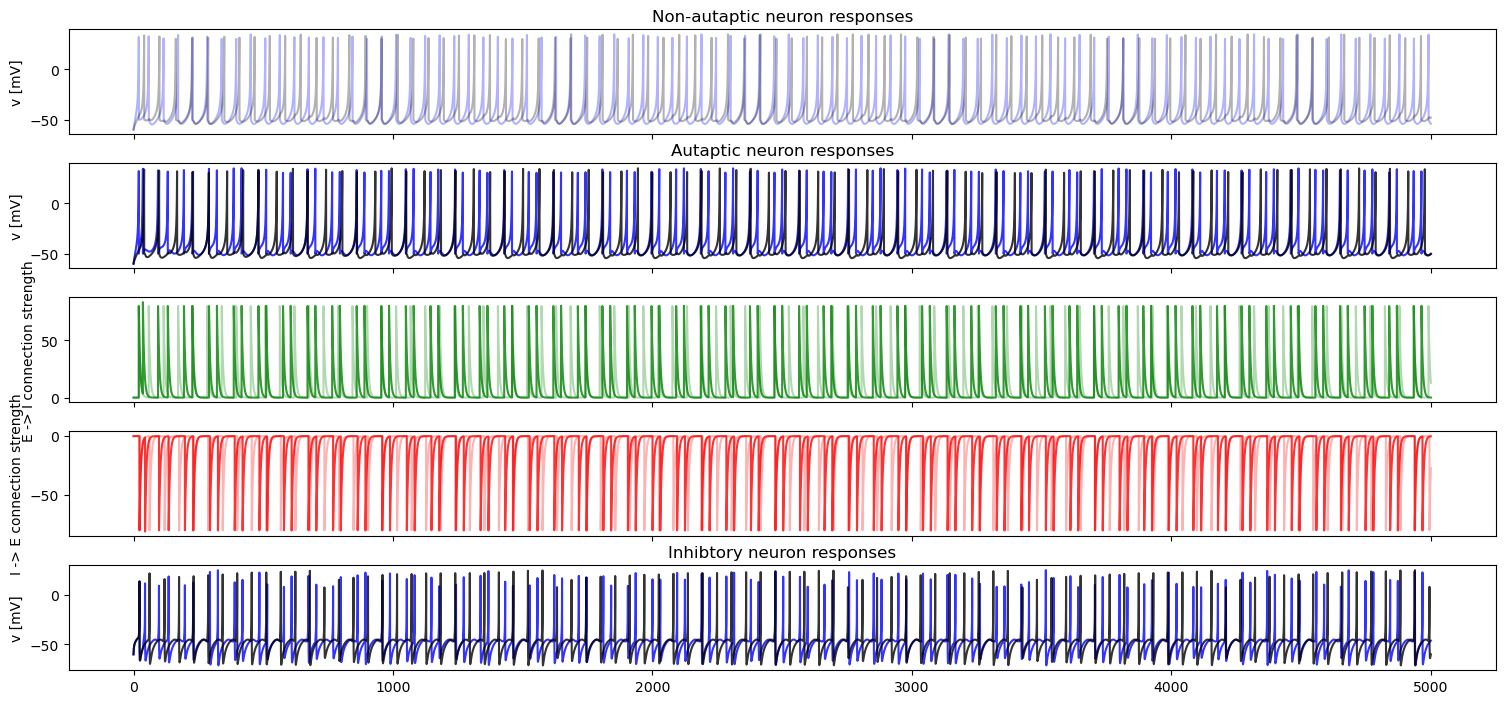

In [6]:
### Plot the outputs for each trial

# 1. SIMPLY PLOT THE TRACES

fig, ax = plt.subplots(5, 1, figsize = (15, 7), sharex = True)
fig.tight_layout()

#plot non-autaptic neurons
ax[0].plot(M_v_E.t/ms, M_v_E.v[0], c = 'blue', alpha = 0.3, label = 'non-autaptic neuron 1')
ax[0].plot(M_v_E.t/ms, M_v_E.v[1], c = 'black', alpha = 0.3, label = 'non-autaptic neuron 2')
ax[0].set_title('Non-autaptic neuron responses')
ax[0].set_ylabel('v [mV]')

# plot autaptic neurons
ax[1].plot(M_v_E_aut.t/ms, M_v_E_aut.v[0], c = 'blue', alpha = 0.8, label = 'autaptic neuron 1')
ax[1].plot(M_v_E_aut.t/ms, M_v_E_aut.v[1], c = 'black', alpha = 0.8, label = 'non-autaptic neuron 2')
ax[1].set_title('Autaptic neuron responses')
ax[1].set_ylabel('v [mV]')

# plot synapse variables at the inhibitory neuron
ax[2].plot(M_v_I.t/ms, M_v_I.Syn_exc[0], c = 'green', alpha = 0.3, label = 'NAut - E1 to I')
#ax[2].plot(M_syn_EI.t/ms, M_syn_EI.w_exc[1], c = 'red', alpha = 0.3, label = 'NAut - E2 to I')
ax[2].plot(M_v_I_aut.t/ms, M_v_I_aut.Syn_exc[0], c = 'green', alpha = 0.8, label = 'Aut - E1 to I')
#ax[2].plot(M_syn_EI_aut.t/ms, M_syn_EI_aut.w_exc[1], c = 'red', alpha = 0.8, label = 'Aut - E2 to I')
ax[2].set_ylabel("E -> I connection strength")

# plot synapse variables at the inhibitory neuron
#ax[3].plot(M_syn_IE.t/ms, M_syn_IE.w_inh[0], c = 'green', alpha = 0.3, label = 'NAut - E1 to I')
ax[3].plot(M_v_E.t/ms, M_v_E.Syn_inh[1], c = 'red', alpha = 0.3, label = 'NAut - I to E2')
#ax[3].plot(M_syn_IE_aut.t/ms, M_syn_IE_aut.w_inh[0], c = 'green', alpha = 0.8, label = 'Aut - E1 to I')
ax[3].plot(M_v_E_aut.t/ms, M_v_E_aut.Syn_inh[1], c = 'red', alpha = 0.8, label = 'Aut - I to E2')
ax[3].set_ylabel("I -> E connection strength")

ax[4].plot(M_v_I_aut.t/ms, M_v_I_aut.v[0], c = 'blue', alpha = 0.8, label = 'inhibitory neuron net 1')
ax[4].plot(M_v_I.t/ms, M_v_I.v[0], c = 'black', alpha = 0.8, label = 'inhibitory neuron net 2')
ax[4].set_title('Inhibtory neuron responses')
ax[4].set_ylabel('v [mV]')


Text(103.72222222222221, 0.5, 'fft')

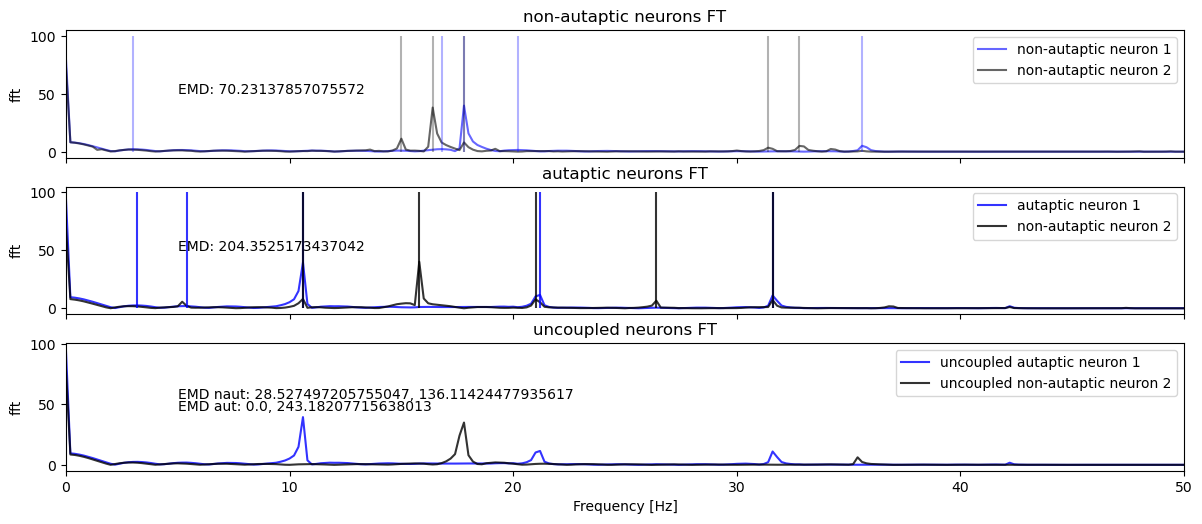

In [22]:
''' - - -  2. PLOT THE FOURIER TRANSFORMS OF THE SPIKING ACTIVITY - - - '''
#binarise spike trains
spikes_E = convert_spikes_to_aqua(spike_trains_E)
spikes_E_aut = convert_spikes_to_aqua(spike_trains_E_aut)
spikes_E_uncoupled = convert_spikes_to_aqua(spike_trains_E_uncoupled)

binary_E = binarise_spikes(spikes_E, dt, N_iter)
binary_E_aut = binarise_spikes(spikes_E_aut, dt, N_iter)
binary_E_uncoupled = binarise_spikes(spikes_E_uncoupled, dt, N_iter)


# create filter
gauss = windows.gaussian(M = 10000, std = 100)
gauss /= gauss.sum()    # normalise

# - - CONVOLVE - - 
# convolve non-autaptic spike trains
freqE1 = convolve(binary_E[0, :], gauss)[:len(binary_E[0, :])]
freqE2 = convolve(binary_E[1, :], gauss)[:len(binary_E[1, :])]
# convolve autaptic spike trains
freqE1_aut = convolve(binary_E_aut[0, :], gauss)[:len(binary_E_aut[0, :])]
freqE2_aut = convolve(binary_E_aut[1, :], gauss)[:len(binary_E_aut[1, :])]
# uncoupled neurons
freqE1_uncoupled = convolve(binary_E_uncoupled[0, :], gauss)[:len(binary_E_uncoupled[0, :])]
freqE2_uncoupled = convolve(binary_E_uncoupled[1, :], gauss)[:len(binary_E_uncoupled[1, :])]


# - - calculate the FFT - - 
fftE1 = np.fft.fft(freqE1)
fftE2 = np.fft.fft(freqE2)

fftE1_aut = np.fft.fft(freqE1_aut)
fftE2_aut = np.fft.fft(freqE2_aut)

fftE1_uncoupled = np.fft.fft(freqE1_uncoupled)
fftE2_uncoupled = np.fft.fft(freqE2_uncoupled)

# x-axis - frequencies
fftfreq = np.fft.fftfreq(N_iter, d = dt/1000)
n_freq = len(fftfreq)//2
frequencies = fftfreq[:n_freq]

max_E1_freq, max_E1 = get_top_fft_peaks(fftE1[:n_freq], frequencies, min_freq = 2, num_peaks = 5)
max_E2_freq, max_E2 = get_top_fft_peaks(fftE2[:n_freq], frequencies, min_freq = 2, num_peaks = 5)

max_E1_aut_freq, max_E1_aut = get_top_fft_peaks(fftE1_aut[:n_freq], frequencies, min_freq = 2, num_peaks = 5)
max_E2_aut_freq, max_E2_aut = get_top_fft_peaks(fftE2_aut[:n_freq], frequencies, min_freq = 2, num_peaks = 5)


## Calculate the Wasserstein/EMD distance
EMD_naut = wasserstein_distance(frequencies, frequencies, np.abs(fftE1[:n_freq]), np.abs(fftE2[:n_freq]))
EMD_aut = wasserstein_distance(frequencies, frequencies, np.abs(fftE1_aut[:n_freq]), np.abs(fftE2_aut[:n_freq]))

EMD_nautE1_uncoupled = wasserstein_distance(frequencies, frequencies, np.abs(fftE1[:n_freq]), np.abs(fftE1_uncoupled[:n_freq]))
EMD_autE1_uncoupled = wasserstein_distance(frequencies, frequencies, np.abs(fftE1_aut[:n_freq]), np.abs(fftE1_uncoupled[:n_freq]))
EMD_nautE2_uncoupled = wasserstein_distance(frequencies, frequencies, np.abs(fftE2[:n_freq]), np.abs(fftE2_uncoupled[:n_freq]))
EMD_autE2_uncoupled = wasserstein_distance(frequencies, frequencies, np.abs(fftE2_aut[:n_freq]), np.abs(fftE2_uncoupled[:n_freq]))

fig, ax = plt.subplots(3, 1, figsize = (12, 5), sharex = True)
fig.tight_layout()

ax[0].plot(fftfreq[:len(fftfreq)//2], np.abs(fftE1[:len(fftfreq)//2]), c = 'blue', alpha = 0.6, label = 'non-autaptic neuron 1')
ax[0].plot(fftfreq[:len(fftfreq)//2], np.abs(fftE2[:len(fftfreq)//2]), c = 'black', alpha = 0.6, label = 'non-autaptic neuron 2')
ax[0].vlines(max_E1_freq, ymin = np.zeros(len(max_E1)), ymax = 100*np.ones(len(max_E1)), color = 'blue', alpha = 0.3)
ax[0].vlines(max_E2_freq, ymin = np.zeros(len(max_E2)), ymax = 100*np.ones(len(max_E2)), color = 'black', alpha = 0.3)
ax[0].text(5, 50, f'EMD: {EMD_naut}')
ax[0].legend()

ax[1].plot(fftfreq[:len(fftfreq)//2], np.abs(fftE1_aut[:len(fftfreq)//2]), c = 'blue', alpha = 0.8, label = 'autaptic neuron 1')
ax[1].plot(fftfreq[:len(fftfreq)//2], np.abs(fftE2_aut[:len(fftfreq)//2]), c = 'black', alpha = 0.8, label = 'non-autaptic neuron 2')
ax[1].vlines(max_E1_aut_freq, ymin = np.zeros(len(max_E1_aut)), ymax = 100*np.ones(len(max_E1_aut)), color = 'blue', alpha = 0.8)
ax[1].vlines(max_E2_aut_freq, ymin = np.zeros(len(max_E2_aut)), ymax = 100*np.ones(len(max_E2_aut)), color = 'black', alpha = 0.8)
ax[1].text(5, 50, f'EMD: {EMD_aut}')
ax[1].legend()

ax[2].plot(fftfreq[:len(fftfreq)//2], np.abs(fftE1_uncoupled[:len(fftfreq)//2]), c = 'blue', alpha = 0.8, label = 'uncoupled autaptic neuron 1')
ax[2].plot(fftfreq[:len(fftfreq)//2], np.abs(fftE2_uncoupled[:len(fftfreq)//2]), c = 'black', alpha = 0.8, label = 'uncoupled non-autaptic neuron 2')
ax[2].text(5, 55, f'EMD naut: {EMD_nautE1_uncoupled}, {EMD_nautE2_uncoupled}')
ax[2].text(5, 45, f'EMD aut: {EMD_autE1_uncoupled}, {EMD_autE2_uncoupled}')
ax[2].legend()


ax[0].set_xlim((0, 50))
ax[1].set_xlim((0, 50))
ax[2].set_xlim((0, 50))

ax[0].set_title('non-autaptic neurons FT')
ax[1].set_title('autaptic neurons FT')
ax[2].set_title('uncoupled neurons FT')
ax[2].set_xlabel("Frequency [Hz]")
ax[0].set_ylabel('fft')
ax[1].set_ylabel('fft')
ax[2].set_ylabel('fft')

In [8]:
'''FT distance'''
# calculate FFT
_, freq = calculate_FT(binary_E_aut[0, :], dt, gauss)
fft_E1_aut = calculate_FT(binary_E_aut[0, :], dt, gauss)[0]
fft_E2_aut = calculate_FT(binary_E_aut[1, :], dt, gauss)[0]

fft_E1_naut = calculate_FT(binary_E[0, :], dt, gauss)[0]
fft_E2_naut = calculate_FT(binary_E[1, :], dt, gauss)[0]

diff_aut = calculate_FT_diff(fft_E1_aut, fft_E2_aut, freq)
diff_naut = calculate_FT_diff(fft_E1_naut, fft_E2_naut, freq)

print(diff_aut)
print(diff_naut)


0.6323784871160405
0.6803703027725337


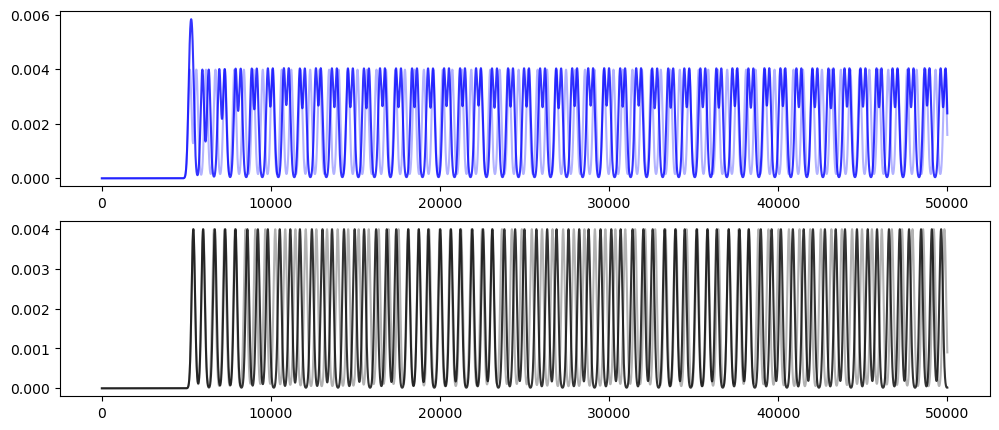

In [9]:

fig, ax = plt.subplots(2, 1, figsize = (12, 5))

ax[0].plot(freqE1, c = 'blue', alpha = 0.3)
ax[0].plot(freqE1_aut, c = 'blue', alpha = 0.8)

ax[1].plot(freqE2, c = 'black', alpha = 0.3)
ax[1].plot(freqE2_aut, c = 'black', alpha = 0.8)


17.730529897676536
NON-AUTAPTIC: 0.9291366142495927
AUTAPTIC: 0.8998534128083918


Text(0.5, 1.0, 'E2 firing rate')

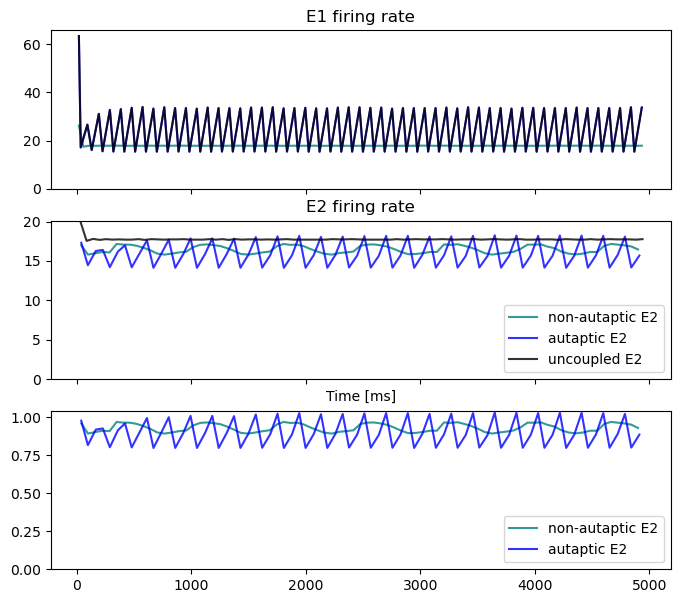

In [10]:
## Some metrics based on the firing frequency... Maybe just the steady-state firing rate?
freq_E = 1000/np.diff(spikes_E, axis = 1)
freq_E_aut = 1000/np.diff(spikes_E_aut, axis = 1)
freq_E_uncoupled = 1000/np.diff(spikes_E_uncoupled, axis = 1)
# adjust frequency relative to uncoupled state
ref_freq = np.mean(freq_E_uncoupled[1, ~np.isnan(freq_E_uncoupled[1, :])][-10:])
print(ref_freq)

rel_freq_E = freq_E/ref_freq
rel_freq_E_aut = freq_E_aut/ref_freq

print(f'NON-AUTAPTIC: {np.mean(rel_freq_E[1, ~np.isnan(rel_freq_E[1, :])])}')
print(f'AUTAPTIC: {np.mean(rel_freq_E_aut[1, ~np.isnan(rel_freq_E_aut[1, :])])}')

time = np.linspace(0, T, N_iter)

fig, ax = plt.subplots(3, 1, figsize = (8, 7), sharex = True)

ax[0].plot(spikes_E[0, :-1], freq_E[0], c = 'teal', alpha = 0.8, label = 'non-autaptic E1')
ax[0].plot(spikes_E_aut[0, :-1], freq_E_aut[0], c = 'b', alpha = 0.8, label = 'autaptic E1')
ax[0].plot(spikes_E_uncoupled[0, :-1], freq_E_uncoupled[0], c = 'black', alpha = 0.8, label = 'uncoupled E1')

ax[1].plot(spikes_E[1, :-1], freq_E[1], c = 'teal', alpha = 0.8, label = 'non-autaptic E2')
ax[1].plot(spikes_E_aut[1, :-1], freq_E_aut[1], c = 'b', alpha = 0.8, label = 'autaptic E2')
ax[1].plot(spikes_E_uncoupled[1, :-1], freq_E_uncoupled[1], c = 'black', alpha = 0.8, label = 'uncoupled E2')
ax[1].legend(loc = 'lower right')

ax[2].plot(spikes_E[1, :-1], rel_freq_E[1], c = 'teal', alpha = 0.8, label = 'non-autaptic E2')
ax[2].plot(spikes_E_aut[1, :-1], rel_freq_E_aut[1], c = 'b', alpha = 0.8, label = 'autaptic E2')
ax[2].legend(loc = 'lower right')
ax[2].set_ylim(bottom = 0)

ax[0].set_ylim(bottom = 0)
ax[1].set_ylim(bottom = 0)
ax[1].set_xlabel('Time [ms]')
ax[0].set_title("E1 firing rate")
ax[1].set_title("E2 firing rate")



[6 7 0]
max: [   4.0056146    25.60124329 1334.40084596]
max aut: [   7.13408526   85.30249121 1244.48047147]


Text(12.597222222222223, 0.5, 'fft')

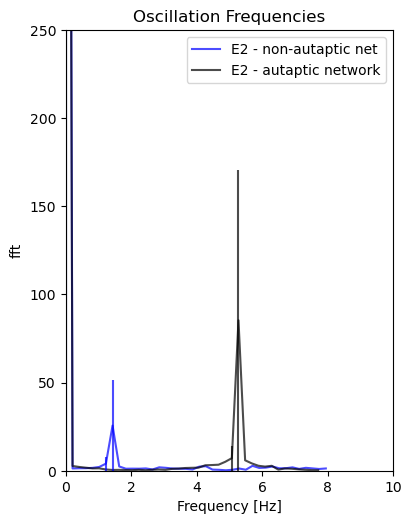

In [11]:
## Extract the frequency of the oscillations with and without autapse.
diff = np.diff(spikes_E[1, ~np.isnan(spikes_E[1, :])])
timestep = np.mean(diff[len(diff)//2:])/1000    # mean over the second half only
fft_frequencies_E = np.fft.fftfreq(len(freq_E[1, ~np.isnan(freq_E[1, :])]), d = timestep)
osc_fft_E = np.fft.fft(freq_E[1, ~np.isnan(freq_E[1, :])])

diff = np.diff(spikes_E_aut[1, ~np.isnan(spikes_E_aut[1, :])])
timestep = np.mean(diff[len(diff)//2:])/1000    # mean over the second half only
fft_frequencies_E_aut = np.fft.fftfreq(len(freq_E_aut[1, ~np.isnan(freq_E_aut[1, :])]), d = timestep)
osc_fft_E_aut = np.fft.fft(freq_E_aut[1, ~np.isnan(freq_E_aut[1, :])])


# try to extract the peaks and corresponding frequencies
frequencies_E = fft_frequencies_E[:len(fft_frequencies_E)//2]
N_e = len(frequencies_E)
frequencies_E_aut = fft_frequencies_E_aut[:len(fft_frequencies_E_aut)//2]
N_e_aut = len(frequencies_E_aut)

osc_freq_E = np.abs(osc_fft_E[:N_e])
osc_freq_E_aut = np.abs(osc_fft_E_aut[:N_e_aut])

max_E_idx = np.argsort(osc_freq_E)[-3:]
print(max_E_idx)
max_E_aut_idx = np.argsort(osc_freq_E_aut)[-3:]

max_E = osc_freq_E[max_E_idx]
max_E_freq = frequencies_E[max_E_idx]
print(f"max: {max_E}")
max_E_aut = osc_freq_E_aut[max_E_aut_idx]
max_E_aut_freq = frequencies_E_aut[max_E_aut_idx]
print(f"max aut: {max_E_aut}")

fig, ax = plt.subplots(1, 1, figsize = (4, 5), sharex = True)
fig.tight_layout()

ax.plot(frequencies_E, osc_freq_E, c = 'blue', alpha = 0.7, label = 'E2 - non-autaptic net')
ax.plot(frequencies_E_aut, osc_freq_E_aut, c = 'black', alpha = 0.7, label = 'E2 - autaptic network')
ax.vlines(max_E_freq, ymin = np.zeros(len(max_E)), ymax = 2*max_E, color = 'blue', alpha = 0.7)
ax.vlines(max_E_aut_freq, ymin = np.zeros(len(max_E_aut)), ymax = 2*max_E_aut, color = 'black', alpha = 0.7)
ax.legend()

ax.set_xlim((0, 10))
ax.set_ylim((0, 250))

ax.set_title('Oscillation Frequencies')
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel('fft')


In [12]:
# Find a motif in the data based on the stumpy

import stumpy

naut_overlay = M_v_E.v[0] + M_v_E.v[1]
aut_overlay = M_v_E_aut.v[0] + M_v_E_aut.v[1]

window = 4000
mp_naut = stumpy.stump(naut_overlay, window) 
mp_aut = stumpy.stump(aut_overlay, window)

motif_idx_naut = np.argsort(mp_naut[:, 0])[0]
motif_idx_aut = np.argsort(mp_aut[:, 0])[0]

nearest_neighbour_naut = mp_naut[motif_idx_naut, 1]
nearest_neighbour_aut = mp_aut[motif_idx_aut, 1]

In [13]:
def plot_mat_profile(x, time_x, mp, window, motif_idx, nearest_neigh):
    # plot the time series, matrix profile and recurring motif
    fig, ax = plt.subplots(3, 1, figsize = (15, 7), sharex = True)
    fig.tight_layout()
    time = np.linspace(1, int(window*dt), window)

    # plot non-autaptic neurons
    ax[0].plot(time_x, x, c = 'blue', alpha = 0.3, label = 'non-autaptic neuron 1')
    ax[0].set_title('Non-autaptic neuron responses')
    ax[0].set_ylabel('v [mV]')

    ax[1].plot(time_x[:-(window-1)], mp[:, 0])

    ax[2].plot(time, x[motif_idx:motif_idx + window], c = 'green')
    ax[2].plot(time, x[nearest_neigh:nearest_neigh+ window], c = 'orange')

    return fig, ax


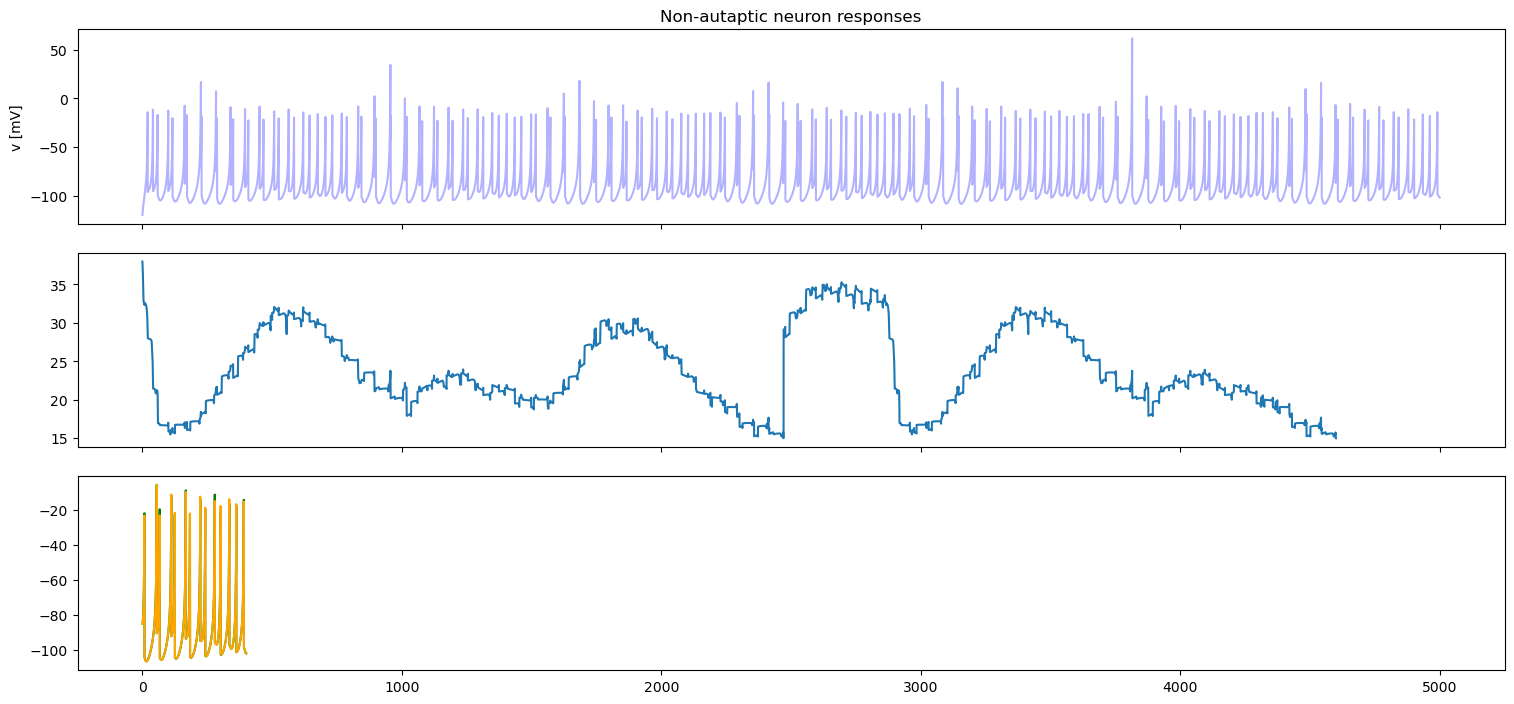

In [14]:
fig, ax = plot_mat_profile(naut_overlay, M_v_E.t/ms, mp_naut, window, motif_idx_naut, nearest_neighbour_naut)

plt.show()

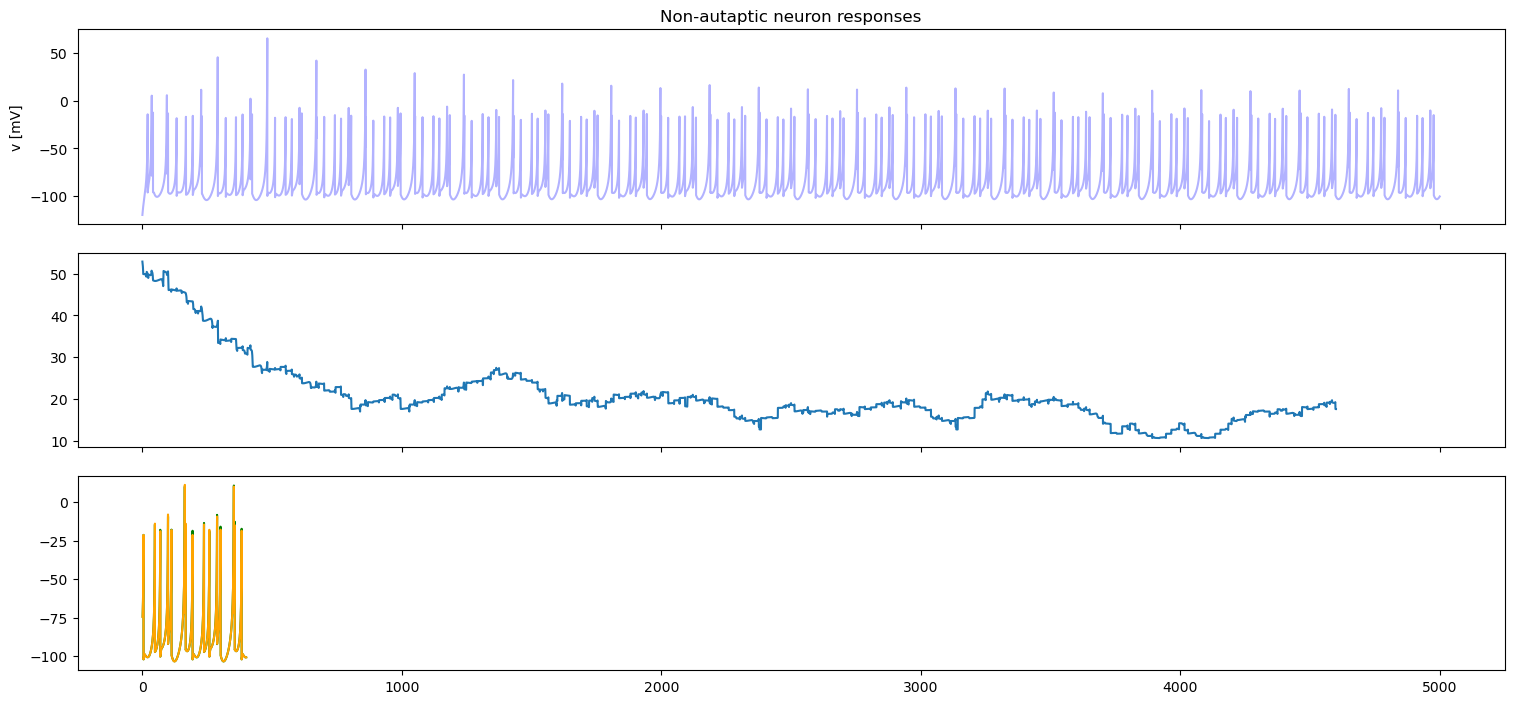

In [15]:
fig, ax = plot_mat_profile(aut_overlay, M_v_E.t/ms, mp_aut, window, motif_idx_aut, nearest_neighbour_aut)

plt.show()